# Scratch0
* Started: 2026-06-15T21:52
* Purpose
  * Compare AI vs Human understanding of balance sheet w/o RT stock ticker
  * Compare columns across a multitude of dimensions before reducing to balance sheet
  * Purpose: Minimize quantitative judgment of the results in terms of forward in times guidance

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
data_raw = pd.read_csv('data/cash_app_report_1781573300298.csv')
data_raw

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
0,2026-06-16 00:00:00 EDT,NaN,Stock Dividends,USD,$0.20,$0.00,$0.20,MCD,NaN,NaN,COMPLETE,$0.20 Dividend from McDonald's,NaN,Cash Balance
1,2026-06-15 21:27:11 EDT,NaN,Bitcoin Buy,USD,-$4.90,-$0.10,-$5.00,BTC,"$66,797.17",0.000073,COMPLETE,purchase of BTC 0.00007336,NaN,Cash Balance
2,2026-06-15 20:53:31 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,MRK,$114.97,0.086980,WAITING_ON_EXTERNAL,Scheduled $10 Purchase of Merck,NaN,Cash Balance
3,2026-06-15 20:53:12 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,CRUS,$165.99,0.060240,WAITING_ON_EXTERNAL,Scheduled $10 Purchase of Cirrus Logic,NaN,Cash Balance
4,2026-06-15 20:28:48 EDT,NaN,Stock Buy,USD,-$5.00,$0.00,-$5.00,DUK,$125.31,0.039900,WAITING_ON_EXTERNAL,Scheduled $5 Purchase of Duke Energy,NaN,Cash Balance
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
458,2025-09-16 19:42:27 EDT,#D-QVL3M3DK,P2P,USD,$70.00,$0.00,$70.00,NaN,NaN,NaN,COMPLETE,Camping,Full Name,Cash Balance
459,2025-08-22 12:07:20 EDT,NaN,Account Notifications,USD,$0.00,NaN,$0.00,NaN,NaN,NaN,COMPLETE,New device login,NaN,Cash Balance
460,2022-11-28 10:28:53 EST,7bg2rwg,P2P,USD,-$20.00,$0.00,-$20.00,NaN,NaN,NaN,COMPLETE,baby gift,Mark Brown,Wells Fargo Bank
461,2022-10-07 12:05:33 EDT,q3ryf2r,P2P,USD,-$10.00,$0.00,-$10.00,NaN,NaN,NaN,COMPLETE,Baby gift contribution,Ilana Reeves,Wells Fargo Bank


In [3]:
data_raw['Asset Amount'].fillna(None).astype(float)

0           NaN
1      0.000073
2      0.086980
3      0.060240
4      0.039900
         ...   
458         NaN
459         NaN
460         NaN
461         NaN
462         NaN
Name: Asset Amount, Length: 463, dtype: float64

In [4]:
data = data_raw.copy()
data["date"] = (
    data["Date"]
    .astype(str)
    .str.replace(r"\bEDT\b", "-0400", regex=True)
    .str.replace(r"\bEST\b", "-0500", regex=True)
)

data["date"] = pd.to_datetime(data["date"], format="mixed", utc=True)
del data['Date']


def parse_amount(amount_str: str | None):
    if not isinstance(amount_str, str) or amount_str is None:
        return 0.0
    amount_str = amount_str.replace('$', '').replace(',', '').strip()
    return float(amount_str)


data['net_amount'] = data['Net Amount'].fillna(None).map(parse_amount)
data['amount'] = data['Amount'].fillna(None).map(parse_amount)
data['asset_price'] = data['Asset Price'].fillna(None).map(parse_amount)
data['asset_amount'] = data_raw['Asset Amount'].astype(float).fillna(0.0)
data['fee'] = data['Fee'].fillna(None).map(parse_amount)
data['asset_type'] = data['Asset Type']
data['trans_type'] = data['Transaction Type']
data['currency'] = data['Currency']
data['trans_id'] = data['Transaction ID']
data['account'] = data['Account']
data['status'] = data['Status']
data['notes'] = data['Notes']
data['name_trans'] = data['Name of sender/receiver']

for col in ['Net Amount', 'Amount', 'Asset Price', 'Asset Amount', 'Fee', 'Asset Type', 'Transaction Type',
            'Currency', 'Transaction ID', 'Account', 'Status', 'Notes', 'Name of sender/receiver']:
    del data[col]

data

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
0,2026-06-16 04:00:00+00:00,0.2,0.2,0.00,0.000000,0.0,MCD,Stock Dividends,USD,NaN,Cash Balance,COMPLETE,$0.20 Dividend from McDonald's,NaN
1,2026-06-16 01:27:11+00:00,-5.0,-4.9,66797.17,0.000073,-0.1,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00007336,NaN
2,2026-06-16 00:53:31+00:00,-10.0,-10.0,114.97,0.086980,0.0,MRK,Stock Buy,USD,NaN,Cash Balance,WAITING_ON_EXTERNAL,Scheduled $10 Purchase of Merck,NaN
3,2026-06-16 00:53:12+00:00,-10.0,-10.0,165.99,0.060240,0.0,CRUS,Stock Buy,USD,NaN,Cash Balance,WAITING_ON_EXTERNAL,Scheduled $10 Purchase of Cirrus Logic,NaN
4,2026-06-16 00:28:48+00:00,-5.0,-5.0,125.31,0.039900,0.0,DUK,Stock Buy,USD,NaN,Cash Balance,WAITING_ON_EXTERNAL,Scheduled $5 Purchase of Duke Energy,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
458,2025-09-16 23:42:27+00:00,70.0,70.0,0.00,0.000000,0.0,NaN,P2P,USD,#D-QVL3M3DK,Cash Balance,COMPLETE,Camping,Full Name
459,2025-08-22 16:07:20+00:00,0.0,0.0,0.00,0.000000,0.0,NaN,Account Notifications,USD,NaN,Cash Balance,COMPLETE,New device login,NaN
460,2022-11-28 15:28:53+00:00,-20.0,-20.0,0.00,0.000000,0.0,NaN,P2P,USD,7bg2rwg,Wells Fargo Bank,COMPLETE,baby gift,Mark Brown
461,2022-10-07 16:05:33+00:00,-10.0,-10.0,0.00,0.000000,0.0,NaN,P2P,USD,q3ryf2r,Wells Fargo Bank,COMPLETE,Baby gift contribution,Ilana Reeves


In [5]:
data.nunique().sort_values(ascending=False)

asset_price     375
date            371
asset_amount    370
notes           277
asset_type      162
amount           38
net_amount       35
trans_type        9
trans_id          7
fee               6
account           5
name_trans        5
status            3
currency          1
dtype: int64

In [6]:
data['asset_type'].value_counts()

asset_type
BTC     22
XYZ     10
MCD      9
JPM      9
AMZN     8
        ..
VBR      1
TGT      1
SBUX     1
TSM      1
NVDA     1
Name: count, Length: 162, dtype: int64

In [7]:
(data
 .groupby('asset_type')
 ['amount']
 .apply(tuple)
 .to_frame()
 .assign(number=lambda df: df['amount'].apply(len))
 .assign(total=lambda df: df['amount'].apply(sum))
 .assign(amounts=lambda df: df['amount'].apply(frozenset).apply(sorted).apply(tuple))
 .drop(columns=['amount'])
 .assign(uniq_amounts=lambda df: df['amounts'].apply(len))
 .sort_values(by='number', ascending=False)
 )

,number,total,amounts,uniq_amounts
asset_type,,,,
BTC,22,-207.36,"(-24.5, -9.8, -4.9, -0.98, 20.0)",5
XYZ,10,-166.00,"(-50.0, -25.0, -20.0, -10.0, -1.0)",5
MCD,9,-89.80,"(-25.0, -10.0, -5.0, 0.2)",4
JPM,9,-70.00,"(-25.0, -10.0, -5.0, 20.0)",4
V,8,-96.00,"(-25.0, -20.0, -10.0, -1.0)",4
...,...,...,...,...
H,1,-10.00,"(-10.0,)",1
GSLC,1,-10.00,"(-10.0,)",1
GIS,1,-10.00,"(-10.0,)",1


In [8]:
data['currency'].value_counts()

currency
USD    463
Name: count, dtype: int64

In [9]:
data[~data['asset_type'].isna()]  #.groupby('asset_type')['asset_amount'].sum().sort_values(ascending=False)

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
0,2026-06-16 04:00:00+00:00,0.2,0.2,0.00,0.000000,0.0,MCD,Stock Dividends,USD,NaN,Cash Balance,COMPLETE,$0.20 Dividend from McDonald's,NaN
1,2026-06-16 01:27:11+00:00,-5.0,-4.9,66797.17,0.000073,-0.1,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00007336,NaN
2,2026-06-16 00:53:31+00:00,-10.0,-10.0,114.97,0.086980,0.0,MRK,Stock Buy,USD,NaN,Cash Balance,WAITING_ON_EXTERNAL,Scheduled $10 Purchase of Merck,NaN
3,2026-06-16 00:53:12+00:00,-10.0,-10.0,165.99,0.060240,0.0,CRUS,Stock Buy,USD,NaN,Cash Balance,WAITING_ON_EXTERNAL,Scheduled $10 Purchase of Cirrus Logic,NaN
4,2026-06-16 00:28:48+00:00,-5.0,-5.0,125.31,0.039900,0.0,DUK,Stock Buy,USD,NaN,Cash Balance,WAITING_ON_EXTERNAL,Scheduled $5 Purchase of Duke Energy,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
436,2026-05-27 03:38:54+00:00,-25.0,-24.5,76210.00,0.000321,-0.5,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00032148,NaN
452,2026-05-26 14:09:07+00:00,-20.0,-20.0,69.23,0.288890,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$20 Purchase of Block,NaN
453,2026-05-26 14:06:39+00:00,-10.0,-9.8,77672.17,0.000126,-0.2,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00012617,NaN
454,2026-05-24 19:57:02+00:00,-5.0,-4.9,77256.13,0.000063,-0.1,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00006343,NaN


In [10]:
data['trans_type'].value_counts()

trans_type
Stock Buy                    346
Deposits                      59
Bitcoin Buy                   21
Savings Internal Transfer     12
P2P                            6
Stock Dividends                5
Account Notifications          3
Bitcoin Sell                   1
Withdrawal                     1
Name: count, dtype: int64

In [11]:
(data
 .pivot_table(index='asset_type', columns='trans_type', aggfunc='count', values='net_amount', fill_value=0,
              margins=True, margins_name='total')
 .sort_values(by='total', ascending=False)
 )

trans_type,Bitcoin Buy,Bitcoin Sell,Stock Buy,Stock Dividends,total
asset_type,,,,,
total,21,1,346,5,373
BTC,21,1,0,0,22
XYZ,0,0,10,0,10
MCD,0,0,8,1,9
AMZN,0,0,8,0,8
...,...,...,...,...,...
CRCL,0,0,1,0,1
ABNB,0,0,1,0,1
LYFT,0,0,1,0,1


In [12]:
data_btc = data[data['asset_type'] == 'BTC']
data_btc

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
1,2026-06-16 01:27:11+00:00,-5.0,-4.90,66797.17,0.000073,-0.10,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00007336,NaN
51,2026-06-08 16:36:43+00:00,19.6,20.00,63160.58,0.000317,-0.40,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00031665,NaN
131,2026-06-03 19:29:17+00:00,-10.0,-9.80,66010.01,0.000148,-0.20,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00014846,NaN
158,2026-06-03 16:16:50+00:00,-10.0,-9.80,66582.56,0.000147,-0.20,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00014719,NaN
182,2026-06-03 15:14:44+00:00,-1.0,-0.98,66904.02,0.000015,-0.02,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00001465,NaN
279,2026-06-03 13:08:30+00:00,-10.0,-9.80,67420.34,0.000145,-0.20,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00014536,NaN
290,2026-06-02 19:54:00+00:00,-1.0,-0.98,67817.91,0.000014,-0.02,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00001445,NaN
307,2026-06-01 14:38:57+00:00,-10.0,-9.80,71929.33,0.000136,-0.20,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00013624,NaN
365,2026-06-01 10:12:02+00:00,-5.0,-4.90,73289.50,0.000067,-0.10,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00006686,NaN
367,2026-05-30 20:23:14+00:00,-10.0,-9.80,74404.87,0.000132,-0.20,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00013171,NaN


<Axes: xlabel='date'>

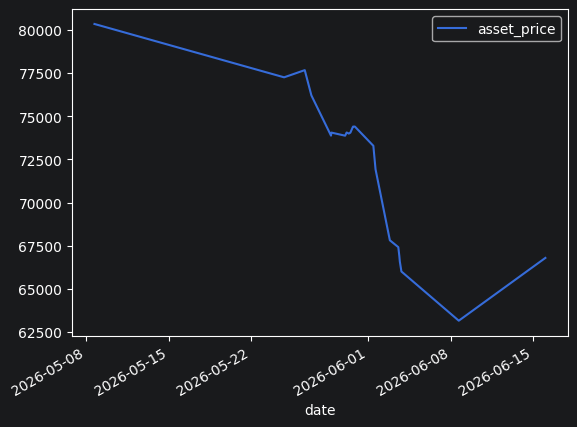

In [13]:
data_btc.plot.line(x='date', y='asset_price')

In [14]:
data_btc['trans_type'].value_counts()

trans_type
Bitcoin Buy     21
Bitcoin Sell     1
Name: count, dtype: int64

In [15]:
data_btc.pivot_table(index='trans_type', aggfunc='sum', values='net_amount')

,net_amount
trans_type,
Bitcoin Buy,-232.0
Bitcoin Sell,19.6


In [16]:
data_btc['net_amount'].sum()

np.float64(-212.4)

In [17]:
trans_btc = data_btc.pivot_table(index='trans_type', aggfunc='sum', values='asset_amount')['asset_amount']
trans_btc

trans_type
Bitcoin Buy     0.003100
Bitcoin Sell    0.000317
Name: asset_amount, dtype: float64

In [18]:
data_btc['asset_amount'].sum()

np.float64(0.00341649)

In [19]:
btc_amount = trans_btc['Bitcoin Buy'] - trans_btc['Bitcoin Sell']
btc_amount

np.float64(0.00278319)

Text(0, 0.5, 'BTC Price')

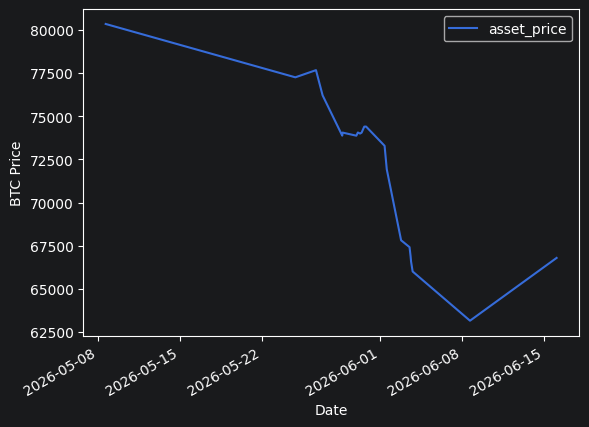

In [20]:
data_btc.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('BTC Price')

Text(0, 0.5, 'Holdings BTC')

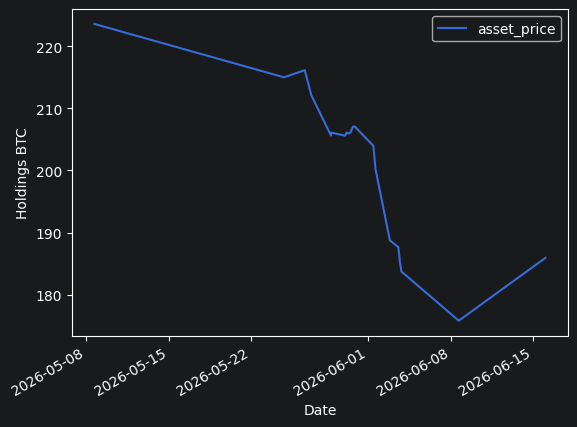

In [21]:
data_btc.assign(asset_price=lambda x: btc_amount * x['asset_price']).plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Holdings BTC')

In [22]:
data_btc['asset_price'] * data_btc['asset_amount']

1       4.900240
51     19.999798
131     9.799846
158     9.800287
182     0.980144
279     9.800221
290     0.979969
307     9.799652
365     4.900136
367     9.799865
370     4.900112
371     9.799903
375     9.799965
379    24.500200
386    24.499951
390    24.500084
409     9.799731
413     9.800031
436    24.499991
453     9.799898
454     4.900356
455     9.799819
dtype: float64

In [23]:
data_xyz = data[data['asset_type'] == 'XYZ']
data_xyz

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
18,2026-06-15 13:32:07+00:00,-10.0,-10.0,72.26,0.13838,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
66,2026-06-04 13:31:36+00:00,-20.0,-20.0,70.84,0.28232,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$20 Purchase of Block,NaN
142,2026-06-03 19:22:37+00:00,-10.0,-10.0,69.87,0.14312,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
154,2026-06-03 16:57:03+00:00,-10.0,-10.0,69.67,0.14353,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
167,2026-06-03 15:50:14+00:00,-10.0,-10.0,69.62,0.14364,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
205,2026-06-03 13:43:52+00:00,-10.0,-10.0,71.59,0.13968,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
208,2026-06-03 13:33:56+00:00,-1.0,-1.0,72.82,0.01373,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$1 Purchase of Block,NaN
311,2026-06-01 13:30:51+00:00,-25.0,-25.0,77.50,0.32258,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$25 Purchase of Block,NaN
396,2026-05-29 13:33:18+00:00,-50.0,-50.0,75.00,0.66666,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$50 Purchase of Block,NaN
452,2026-05-26 14:09:07+00:00,-20.0,-20.0,69.23,0.28889,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$20 Purchase of Block,NaN


Text(0, 0.5, 'Price Block:XYZ')

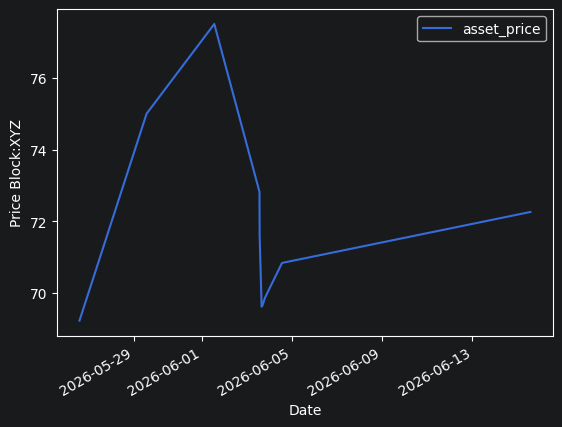

In [24]:
data_xyz.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Price Block:XYZ')

In [25]:
asset_count = data.groupby('asset_type')['amount'].count().sort_values(ascending=False)
asset_count

asset_type
BTC     22
XYZ     10
MCD      9
JPM      9
V        8
        ..
H        1
GSLC     1
GIS      1
GAP      1
ZG       1
Name: amount, Length: 162, dtype: int64

In [26]:
asset_price_time = (
    data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    [asset_count.head(12).iloc[1::].index]
    .dropna(how='all')
)
asset_price_time

asset_type,XYZ,MCD,JPM,V,AMZN,PZZA,UBER,DOW,META,ORCL,WFC
date,,,,,,,,,,,
2026-05-26 14:09:07+00:00,69.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-27 13:30:01+00:00,NaN,NaN,NaN,NaN,266.30,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-27 13:30:04+00:00,NaN,NaN,305.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-27 13:30:09+00:00,NaN,280.24,NaN,NaN,NaN,NaN,NaN,34.6,NaN,NaN,NaN
2026-05-27 13:30:12+00:00,NaN,NaN,NaN,NaN,NaN,32.63,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2026-06-15 13:30:29+00:00,NaN,NaN,NaN,NaN,NaN,NaN,70.73,NaN,NaN,NaN,NaN
2026-06-15 13:32:07+00:00,72.26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-15 21:11:59+00:00,NaN,NaN,NaN,NaN,246.11,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
asset_price_rel = asset_price_time.div(asset_price_time.bfill().iloc[0]).ffill().fillna(1)
asset_price_rel

asset_type,XYZ,MCD,JPM,V,AMZN,PZZA,UBER,DOW,META,ORCL,WFC
date,,,,,,,,,,,
2026-05-26 14:09:07+00:00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2026-05-27 13:30:01+00:00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2026-05-27 13:30:04+00:00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2026-05-27 13:30:09+00:00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2026-05-27 13:30:12+00:00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...
2026-06-15 13:30:29+00:00,1.023256,0.991293,1.024164,0.980772,0.950432,0.991112,1.005687,0.945376,0.934895,1.044386,1.035138
2026-06-15 13:32:07+00:00,1.043767,0.991293,1.024164,0.980772,0.950432,0.991112,1.005687,0.945376,0.934895,1.044386,1.035138
2026-06-15 21:11:59+00:00,1.043767,0.991293,1.024164,0.980772,0.924183,0.991112,1.005687,0.945376,0.934895,1.044386,1.035138


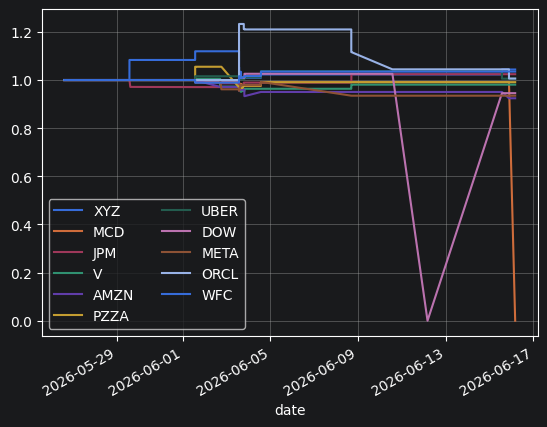

In [28]:
asset_price_rel.plot.line()
plt.grid()
plt.legend(ncols=2)


In [29]:
asset_price_rel['XYZ'].dropna()

date
2026-05-26 14:09:07+00:00    1.000000
2026-05-27 13:30:01+00:00    1.000000
2026-05-27 13:30:04+00:00    1.000000
2026-05-27 13:30:09+00:00    1.000000
2026-05-27 13:30:12+00:00    1.000000
                               ...   
2026-06-15 13:30:29+00:00    1.023256
2026-06-15 13:32:07+00:00    1.043767
2026-06-15 21:11:59+00:00    1.043767
2026-06-15 21:12:19+00:00    1.043767
2026-06-16 04:00:00+00:00    1.043767
Name: XYZ, Length: 83, dtype: float64

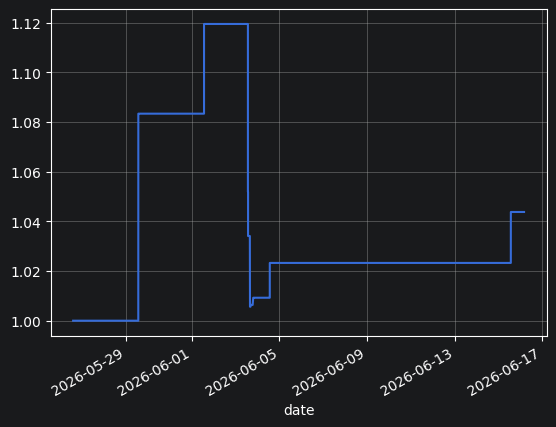

In [30]:
asset_price_rel['XYZ'].dropna().plot.line()
plt.grid()


In [31]:
(data[data['trans_type'] == 'Stock Dividends']
 .drop(columns=['asset_amount', 'fee', 'asset_price', 'trans_id', 'name_trans', 'account', 'currency', 'status'])
 )

,date,net_amount,amount,asset_type,trans_type,notes
0,2026-06-16 04:00:00+00:00,0.20,0.20,MCD,Stock Dividends,$0.20 Dividend from McDonald's
31,2026-06-15 04:00:00+00:00,0.02,0.02,GOOG,Stock Dividends,$0.02 Dividend from Alphabet Inc. Class C
32,2026-06-15 04:00:00+00:00,0.02,0.02,GOOGL,Stock Dividends,$0.02 Dividend from Alphabet Inc. Class A
35,2026-06-12 04:00:00+00:00,0.05,0.05,DOW,Stock Dividends,$0.05 Dividend from Dow
288,2026-06-03 04:00:00+00:00,0.03,0.03,VMBS,Stock Dividends,$0.03 Dividend from Vanguard Mortgage-Backed S...
